In [3]:
# Import cac thu vien can thiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Đã tải thành công các thư viện cần thiết.")

Đã tải thành công các thư viện cần thiết.


In [4]:
# Tải dữ liệu huấn luyện và kiểm thử từ file của bạn
# Mặc định pd.read_csv sẽ tự động lấy dòng đầu tiên làm tiêu đề cột
train_data = pd.read_csv('dataset/NSL_boosted-0.csv')
test_data = pd.read_csv('dataset/NSL_ppTest.csv')

# Loại bỏ cột difficulty_level (nếu có trong file) vì không dùng để dự đoán
# Dùng errors='ignore' để code không bị lỗi nếu file của bạn đã cắt mất cột này từ trước
# Loại bỏ các cột dư thừa không phải là đặc trưng mạng để tránh lỗi và rò rỉ dữ liệu
cols_to_drop = ['difficulty_level', 'atakcat']
train_data = train_data.drop(columns=cols_to_drop, errors='ignore')
test_data = test_data.drop(columns=cols_to_drop, errors='ignore')

# Chuyển đổi nhãn (label/class) thành kiểu nhị phân: 0 là bình thường, 1 là tấn công
# Kiểm tra xem cột nhãn tên là 'class' hay 'label' để xử lý cho đúng
label_col = 'class' if 'class' in train_data.columns else 'label'

train_data[label_col] = train_data[label_col].apply(lambda x: 0 if x == 'normal' else 1)
test_data[label_col] = test_data[label_col].apply(lambda x: 0 if x == 'normal' else 1)

# Mã hóa các cột dạng chữ sang dạng số
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])
    # Xử lý các nhãn lạ ở tập test để tránh lỗi
    test_data[col] = test_data[col].map(lambda s: '<unknown>' if s not in le.classes_ else s)
    le.classes_ = np.append(le.classes_, '<unknown>')
    test_data[col] = le.transform(test_data[col])

# Phân chia đặc trưng (X) và nhãn (y)
X_train = train_data.drop(label_col, axis=1)
y_train = train_data[label_col]
X_test = test_data.drop(label_col, axis=1)
y_test = test_data[label_col]

print("Hoàn thành tiền xử lý dữ liệu. Kích thước tập huấn luyện:", X_train.shape)

Hoàn thành tiền xử lý dữ liệu. Kích thước tập huấn luyện: (126560, 41)


In [5]:
# Khoi tao mo hinh Random Forest voi 100 cay quyet dinh
# Tham so n_jobs=-1 se bat toan bo so luong nhan CPU cua may tinh de huan luyen nhanh nhat
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Dang tien hanh huan luyen mo hinh Random Forest...")
rf_model.fit(X_train, y_train)
print("Huan luyen hoan tat!")

Dang tien hanh huan luyen mo hinh Random Forest...
Huan luyen hoan tat!


In [6]:
# Thuc hien du doan tren tap kiem thu
y_pred = rf_model.predict(X_test)

# Tinh toan cac chi so danh gia
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- KET QUA DANH GIA MO HINH ---")
print(f"Do chinh xac (Accuracy): {acc * 100:.2f}%")
print(f"Do chuan xac (Precision): {prec * 100:.2f}%")
print(f"Do bao phu (Recall): {rec * 100:.2f}%")
print(f"Diem F1 (F1-Score): {f1 * 100:.2f}%")
print("\nBao cao chi tiet phan loai:")
print(classification_report(y_test, y_pred, target_names=['Binh Thuong', 'Tan Cong']))

--- KET QUA DANH GIA MO HINH ---
Do chinh xac (Accuracy): 88.39%
Do chuan xac (Precision): 96.53%
Do bao phu (Recall): 82.57%
Diem F1 (F1-Score): 89.00%

Bao cao chi tiet phan loai:
              precision    recall  f1-score   support

 Binh Thuong       0.81      0.96      0.88      9711
    Tan Cong       0.97      0.83      0.89     12833

    accuracy                           0.88     22544
   macro avg       0.89      0.89      0.88     22544
weighted avg       0.90      0.88      0.88     22544



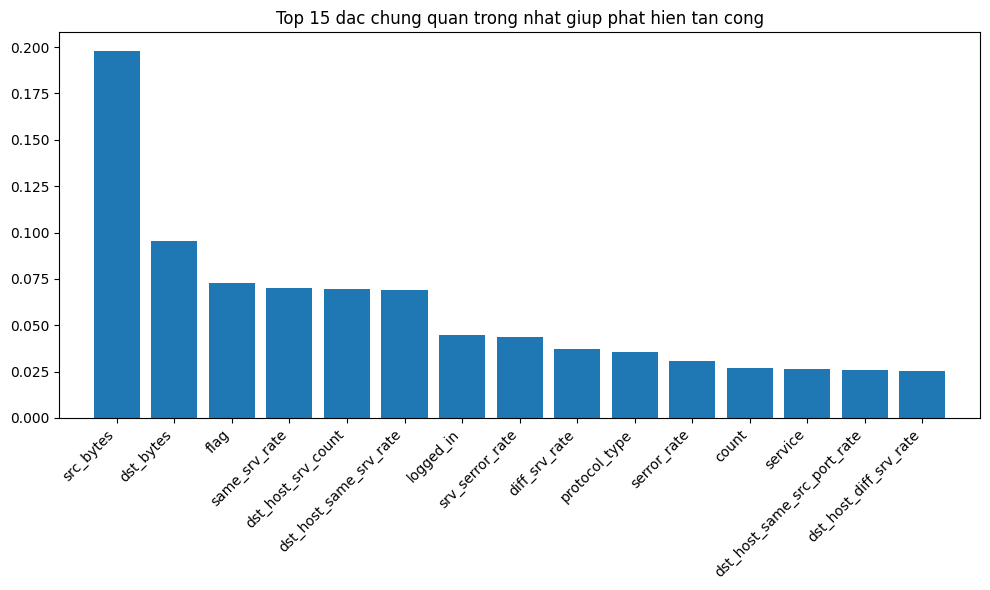

In [7]:
# Trich xuat muc do quan trong cua tung dac chung (Feature Importance)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Lay ra top 15 dac chung quan trong nhat
top_n = 15
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6))
plt.title("Top 15 dac chung quan trong nhat giup phat hien tan cong")
plt.bar(range(top_n), importances[top_indices], align="center")
plt.xticks(range(top_n), [features[i] for i in top_indices], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()

In [8]:
import joblib

# Lưu mô hình đã huấn luyện ra file .pkl
joblib.dump(rf_model, 'ids_model.pkl')
print("Đã lưu mô hình thành công vào file ids_model.pkl!")

Đã lưu mô hình thành công vào file ids_model.pkl!
